# Balancing DQC Agent and Flow

## Set-up

In [2]:
PATH = '../../scratch/aorl2/2026-04-08-00/2026-04-08-00.b7bf8a914965d2ce2cdfd7704faa38b5fee704b874bc391d21e3b9137701759c/'

CKPT_NUM = 1000000

In [3]:
import json
import os

import numpy as np

from agents import agents
from utils.datasets import Dataset, GCDataset, HGCDataset, CGCDataset
from utils.flax_utils import restore_agent

/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead


In [4]:
flags_path = os.path.join(PATH, 'flags.json')
with open(flags_path, 'r') as f:
    saved_flags = json.load(f)

agent_config = saved_flags['agent']
dataset_class_name = agent_config.get('dataset_class', 'GCDataset')
dataset_class = {
    'GCDataset': GCDataset,
    'HGCDataset': HGCDataset,
    'CGCDataset': CGCDataset,
}[dataset_class_name]

dataset_path = os.path.join(PATH, 'data-100000.npz')
dataset_npz = np.load(dataset_path)
train_dataset = dataset_class(Dataset.create(**dict(dataset_npz)), config=agent_config)

seed = saved_flags.get('seed', 0)
example_batch = train_dataset.sample(1)

first_agent = agents[agent_config['agent_name']].create(seed, example_batch, agent_config)
first_agent = restore_agent(first_agent, PATH, CKPT_NUM)

print(f'Restored first_agent from checkpoint {CKPT_NUM}')


Restored from ../../scratch/aorl2/2026-04-08-00/2026-04-08-00.b7bf8a914965d2ce2cdfd7704faa38b5fee704b874bc391d21e3b9137701759c//params_1000000.pkl
Restored first_agent from checkpoint 1000000


In [5]:
dqc_agent = first_agent

In [6]:
from tqdm import tqdm

all_cells = {}

for ob in tqdm(train_dataset.dataset['observations']):
    key = (np.floor(ob[0]), np.floor(ob[1]))
    if key in all_cells:
        all_cells[key] += 1
    else:
        all_cells[key] = 1

all_cell_points = np.asarray(list(all_cells.keys()))

  0%|          | 0/2000000 [00:00<?, ?it/s]

100%|██████████| 2000000/2000000 [00:04<00:00, 410310.89it/s]


## Flow set-up

In [7]:
saved_flags['env_name']

'humanoidmaze-large-navigate-singletask-task5-v0'

In [159]:
config = dict(
    env_name='humanoidmaze-large-navigate-v0',
    # dataset_path='../../scratch/aorl2/YOUR_RUN_DIR/data-1000000.npz',
    dataset_path='../../scratch/data/humanoidmaze-large-navigate-v0/humanoidmaze-large-navigate-v0seed-0.npz',
    observations_key='oracle_reps', # 'observations',
    goal_key='actor_goals',
    actions_key='low_actor_goals', #'actions',
    hidden_dims=(256, 256, 256),
    layer_norm=True,
    lr=3e-4,
    batch_size=256,
    num_train_steps=100000,
    log_interval=100,
    seed=0,
    value_p_curgoal=0.0,
    value_p_trajgoal=1.0,
    value_p_randomgoal=0.0,
    value_geom_sample=False,
    actor_p_curgoal=0.0,
    actor_p_trajgoal=1.0,
    actor_p_randomgoal=0.0,
    actor_geom_sample=True,
    gc_negative=False,
    subgoal_steps=25,
    discount=0.995,
    flow_steps=10,
    backup_horizon=25,
    goal_conditioned=False,
)

config

{'env_name': 'humanoidmaze-large-navigate-v0',
 'dataset_path': '../../scratch/data/humanoidmaze-large-navigate-v0/humanoidmaze-large-navigate-v0seed-0.npz',
 'observations_key': 'oracle_reps',
 'goal_key': 'actor_goals',
 'actions_key': 'low_actor_goals',
 'hidden_dims': (256, 256, 256),
 'layer_norm': True,
 'lr': 0.0003,
 'batch_size': 256,
 'num_train_steps': 100000,
 'log_interval': 100,
 'seed': 0,
 'value_p_curgoal': 0.0,
 'value_p_trajgoal': 1.0,
 'value_p_randomgoal': 0.0,
 'value_geom_sample': False,
 'actor_p_curgoal': 0.0,
 'actor_p_trajgoal': 1.0,
 'actor_p_randomgoal': 0.0,
 'actor_geom_sample': True,
 'gc_negative': False,
 'subgoal_steps': 25,
 'discount': 0.995,
 'flow_steps': 10,
 'backup_horizon': 25,
 'goal_conditioned': False}

In [160]:
from wrappers.datafuncs_utils import make_env_and_datasets

env, base_train_dataset, val_dataset = make_env_and_datasets(
    config['env_name'],
    dataset_path=config['dataset_path'],
    use_oracle_reps=True,
)
train_dataset = CGCDataset(base_train_dataset, config=config)

In [10]:
from utils.networks import ActorVectorField
from __future__ import annotations

from typing import Any

import flax
import flax.linen as nn
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax

from utils.datasets import GCDataset
from utils.flax_utils import TrainState, nonpytree_field
from utils.networks import ActorVectorField, MLP
from wrappers.datafuncs_utils import make_env_and_datasets


In [11]:
class GCFlowGoalProposerAgent(flax.struct.PyTreeNode):
    rng: Any
    network: TrainState
    config: Any = nonpytree_field()

    def flow_loss(self, batch, grad_params=None, rng=None):
        observations = batch[self.config['observations_key']]
        goals = batch[self.config['goal_key']] if self.config['goal_conditioned'] else None
        target_actions = batch[self.config['actions_key']]

        batch_size, action_dim = target_actions.shape
        rng = self.rng if rng is None else rng
        x_rng, t_rng = jax.random.split(rng)

        x_0 = jax.random.normal(x_rng, (batch_size, action_dim))
        t = jax.random.uniform(t_rng, (batch_size, 1))
        x_t = (1.0 - t) * x_0 + t * target_actions
        vel = target_actions - x_0

        pred_vel = self.network(
            observations,
            goals=goals,
            actions=x_t,
            times=t,
            params=grad_params,
        )
        loss = jnp.mean(jnp.square(pred_vel - vel))
        mae = jnp.mean(jnp.abs(pred_vel - vel))
        return loss, {
            'flow_loss': loss,
            'velocity_mae': mae,
        }

    @jax.jit
    def update(self, batch):
        new_rng, rng = jax.random.split(self.rng)

        def loss_fn(grad_params):
            return self.flow_loss(batch, grad_params, rng=rng)

        new_network, info = self.network.apply_loss_fn(loss_fn)
        info['step'] = new_network.step
        return self.replace(rng=new_rng, network=new_network), info

    @jax.jit
    def sample_actions(self, observations, goals, rng):
        single_example = observations.ndim == 1
        if not self.config['goal_conditioned']:
            goals = None
        if single_example:
            observations = observations[None, ...]
            if goals is not None:
                goals = goals[None, ...]

        x = jax.random.normal(rng, (observations.shape[0], self.config['action_dim']))

        for i in range(self.config['flow_steps']):
            t = jnp.full((observations.shape[0], 1), i / self.config['flow_steps'])
            vels = self.network(observations, goals=goals, actions=x, times=t)
            x = x + vels / self.config['flow_steps']

        return x[0] if single_example else x

    @classmethod
    def create(cls, example_batch, config):
        config = dict(config)
        config.setdefault('goal_conditioned', True)
        rng = jax.random.PRNGKey(config['seed'])
        rng, init_rng = jax.random.split(rng)
        action_dim = example_batch[config['actions_key']].shape[-1]
        model = ActorVectorField(
            hidden_dims=tuple(config['hidden_dims']),
            action_dim=action_dim,
            layer_norm=config['layer_norm'],
        )
        init_goals = example_batch[config['goal_key']] if config['goal_conditioned'] else None
        params = model.init(
            init_rng,
            example_batch[config['observations_key']],
            goals=init_goals,
            actions=example_batch[config['actions_key']],
            times=example_batch[config['actions_key']][..., :1],
        )['params']
        network = TrainState.create(model, params, tx=optax.adam(config['lr']))
        config['action_dim'] = action_dim
        return cls(rng=rng, network=network, config=flax.core.FrozenDict(config))

In [12]:
example_batch = train_dataset.sample(1)
flow_agent = GCFlowGoalProposerAgent.create(example_batch, config)
jax.tree_util.tree_map(lambda x: x.shape, flow_agent.network.params)

flow_loss_history = []
velocity_mae_history = []

for step in range(1, config['num_train_steps'] + 1):
    batch = train_dataset.sample(config['batch_size'])
    flow_agent, info = flow_agent.update(batch)

    flow_loss_history.append(float(info['flow_loss']))
    velocity_mae_history.append(float(info['velocity_mae']))

    if step == 1 or step % config['log_interval'] == 0:
        print(
            f"step={step:05d} flow_loss={flow_loss_history[-1]:.6f} velocity_mae={velocity_mae_history[-1]:.6f}"
        )

step=00001 flow_loss=318.009491 velocity_mae=14.859149
step=00100 flow_loss=35.142788 velocity_mae=4.394741
step=00200 flow_loss=18.369354 velocity_mae=3.118624
step=00300 flow_loss=5.069911 velocity_mae=1.687068
step=00400 flow_loss=3.814326 velocity_mae=1.458360
step=00500 flow_loss=2.930463 velocity_mae=1.358631
step=00600 flow_loss=2.284473 velocity_mae=1.177900
step=00700 flow_loss=2.505794 velocity_mae=1.243317
step=00800 flow_loss=2.223557 velocity_mae=1.177281
step=00900 flow_loss=2.553907 velocity_mae=1.249242
step=01000 flow_loss=1.835041 velocity_mae=1.063254
step=01100 flow_loss=2.202329 velocity_mae=1.178687
step=01200 flow_loss=2.101485 velocity_mae=1.150054
step=01300 flow_loss=1.826650 velocity_mae=1.070931
step=01400 flow_loss=2.206034 velocity_mae=1.203315
step=01500 flow_loss=1.923694 velocity_mae=1.099858
step=01600 flow_loss=2.145469 velocity_mae=1.166175
step=01700 flow_loss=1.641642 velocity_mae=1.052865
step=01800 flow_loss=1.832758 velocity_mae=1.069246
step=01

100%|██████████| 200/200 [00:01<00:00, 104.33it/s]


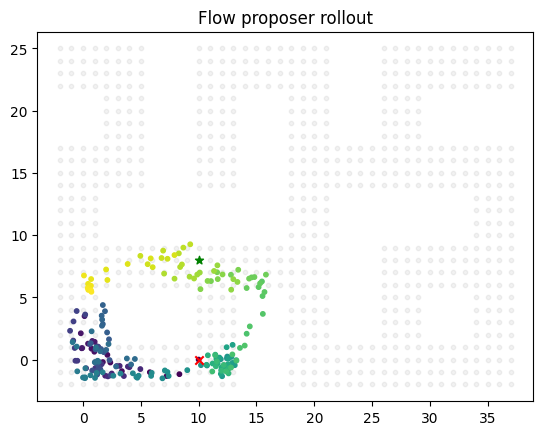

In [13]:
replay_buffer = []
# ob = np.asarray([20.0, 25.0])
# ob = np.asarray([0.0, 8.0])
# ob = np.asarray([5.0, 0.0])
# goal = np.asarray([20.0, 0.0])

# ob = np.asarray([15.0, 20.0])
ob = np.asarray([10.0, 0.0])
goal = np.asarray([20.0, 0.0])
goal = np.asarray([10.0, 8.0])
rng = jax.random.PRNGKey(config['seed'])

for s in tqdm(range(200)):
    replay_buffer.append(ob)
    rng, sample_rng = jax.random.split(rng)
    subgoal = np.asarray(flow_agent.sample_actions(ob, goal, sample_rng))

    if np.linalg.norm(subgoal - ob) < 0.005:
        print(f'reached at step {s}!')
        print('subgoal:', subgoal)
        break
    else:
        ob = subgoal

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

## Utilities

In [23]:
def sample_n(ob, goal, n, sample_rng, agent=flow_agent):
    ob_xy = ob[:2]
    obs = np.repeat(ob_xy[None], n, axis=0)
    goals = np.repeat(goal[None], n, axis=0)

    return flow_agent.sample_actions(obs, goals, sample_rng)

In [24]:
def value_xy(ob, subgoals, goal, agent=dqc_agent):
    assert subgoals.ndim > 1, 'did not provide multiple subgoals'
    subgoal_obs = np.repeat(ob[None], len(subgoals), axis=0)
    subgoal_obs[..., :2] = subgoals
    goals = np.repeat(goal[None], len(subgoals), axis=0)

    vs = agent.network.select('value')(subgoal_obs, goals)
    return vs

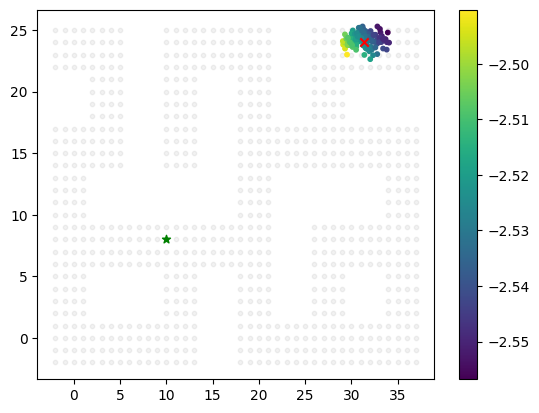

In [45]:
ob = train_dataset.dataset['observations'][12000]

sample_rng, rng = jax.random.split(rng)
subgoals = sample_n(ob, goal, 128, sample_rng)
vs = value_xy(ob, subgoals, goal)

plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
c = plt.scatter(x=subgoals[..., 0], y=subgoals[..., 1], c=vs, cmap='viridis', s=10)
plt.scatter(x=ob[0], y=ob[1], c='red', marker='x')
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.colorbar(c)
plt.show()

/tmp/ipykernel_2329547/531988712.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 4 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  plt.colorbar(c)


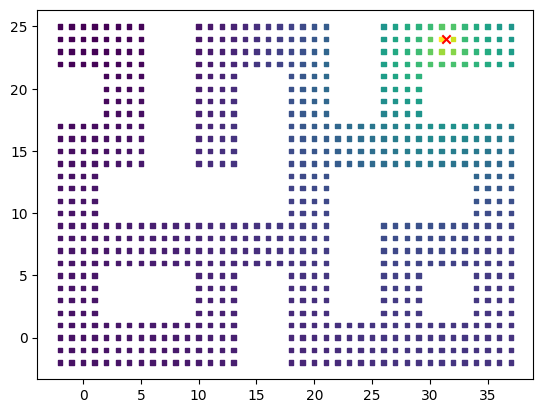

In [32]:
all_obs = np.repeat(ob[None], len(all_cell_points), axis=0)
ob_to_subgoal = dqc_agent.network.select('value')(all_obs, all_cell_points)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=1.0, marker='s', c=ob_to_subgoal)
plt.scatter(x=ob[0], y=ob[1], c='red', marker='x')
# plt.scatter(x=goal[0], y=[1], c='green', marker='*')
plt.colorbar(c)
plt.show()

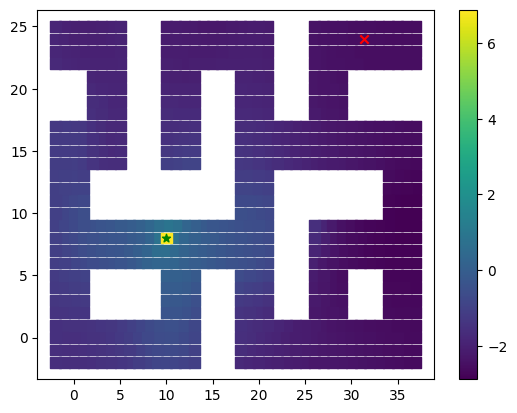

In [47]:
# all_obs = np.repeat(ob[None], len(all_cell_points), axis=0)
# ob = train_dataset.dataset['observations'][12000]
subgoal_to_goal = value_xy(ob, all_cell_points, goal)
# subgoal_obs = np.repeat(ob[None], len(all_cell_points), axis=0)
# # subgoal_obs[..., :2] = all_cell_points

# for i in range(len(all_cell_points)):
#     subgoal_obs[i, 0] = all_cell_points[i][0]
#     subgoal_obs[i, 1] = all_cell_points[i][1]

# goals = np.repeat(goal[None], len(all_cell_points), axis=0)
# print(goal)

# subgoal_to_goal = dqc_agent.network.select('value')(subgoal_obs, goals)

c = plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=60, alpha=1.0, marker='s', c=subgoal_to_goal)
plt.scatter(x=ob[0], y=ob[1], c='red', marker='x')
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.colorbar(c)
plt.show()

In [48]:
dqc_agent.config['discount']

0.995

In [52]:
def sigmoid(x):
    x = np.asarray(x)
    return np.where(
        x >= 0,
        1 / (1 + np.exp(-x)),
        np.exp(x) / (1 + np.exp(x)),
    )


In [63]:
def dynamical_distance(ob, subgoals, goal, agent=dqc_agent):

    all_obs = np.repeat(ob[None], len(subgoals), axis=0)
    ob_to_subgoal_vs = agent.network.select('value')(all_obs, subgoals)
    subgoal_to_goal_vs = value_xy(ob, subgoals, goal)
    ob_to_goal_v = agent.network.select('value')(ob, goal)

    ob_to_subgoal_vs = sigmoid(ob_to_subgoal_vs)
    subgoal_to_goal_vs = sigmoid(subgoal_to_goal_vs)
    ob_to_goal_v = sigmoid(ob_to_goal_v)

    gamma_to_subgoal = np.log(np.clip(ob_to_subgoal_vs, 1e-6, 1.0)) / np.log(dqc_agent.config['discount'])
    gamma_to_goal = np.log(np.clip(subgoal_to_goal_vs, 1e-6, 1.0)) / np.log(dqc_agent.config['discount'])
    ob_to_goal = np.log(np.clip(ob_to_goal_v, 1e-6, 1.0)) / np.log(dqc_agent.config['discount'])

    return gamma_to_subgoal, gamma_to_goal, ob_to_goal

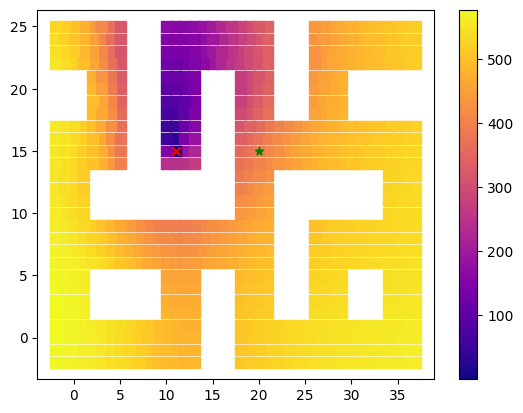

In [64]:
gamma_to_subgoal, gamma_to_goal, ob_to_goal = dynamical_distance(ob, all_cell_points, goal)

c = plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=60, alpha=1.0, marker='s', c=gamma_to_subgoal, cmap='plasma')
plt.scatter(x=ob[0], y=ob[1], c='red', marker='x')
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.colorbar(c)
plt.show()

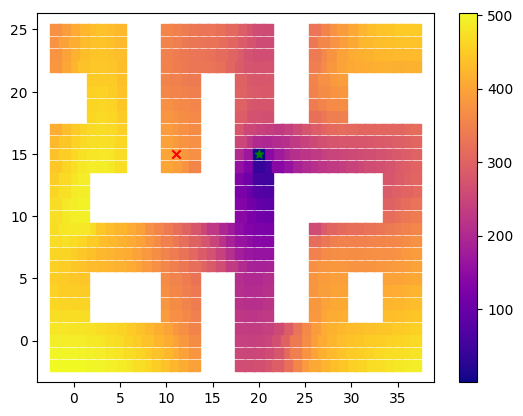

In [65]:
c = plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=60, alpha=1.0, marker='s', c=gamma_to_goal, cmap='plasma')
plt.scatter(x=ob[0], y=ob[1], c='red', marker='x')
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.colorbar(c)
plt.show()

  7%|▋         | 137060/2000000 [00:00<00:07, 260850.55it/s]


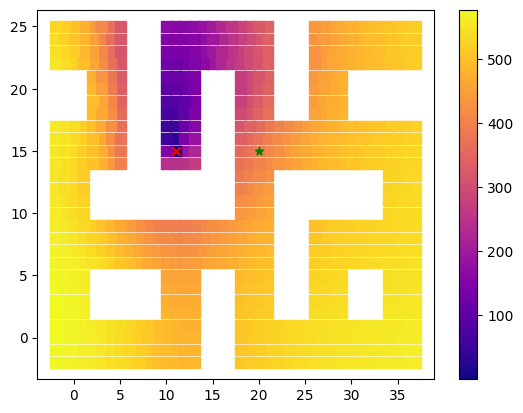

In [66]:
start = np.asarray([11.0, 15.0])
for temp_ob in tqdm(train_dataset.dataset['observations']):
    if np.linalg.norm(temp_ob[:2] - start) < 0.05:
        ob = temp_ob
        break
        # print('no such observation')

goal = np.asarray([20.0, 15.0])

gamma_to_subgoal, gamma_to_goal, ob_to_goal = dynamical_distance(ob, all_cell_points, goal)

c = plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=60, alpha=1.0, marker='s', c=gamma_to_subgoal, cmap='plasma')
plt.scatter(x=ob[0], y=ob[1], c='red', marker='x')
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.colorbar(c)
plt.show()

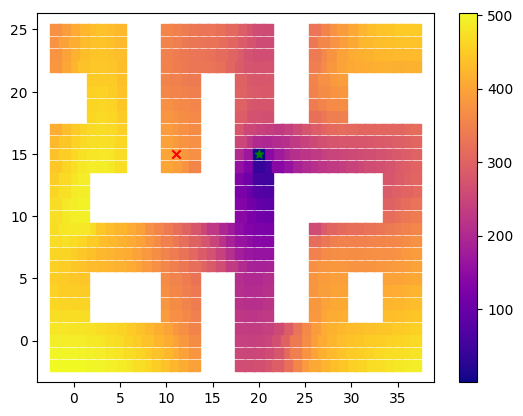

In [67]:
c = plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=60, alpha=1.0, marker='s', c=gamma_to_goal, cmap='plasma')
plt.scatter(x=ob[0], y=ob[1], c='red', marker='x')
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.colorbar(c)
plt.show()

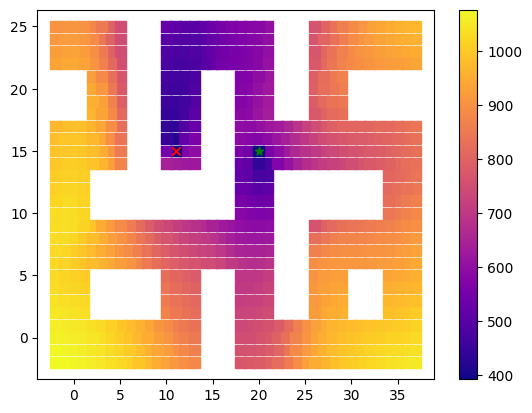

In [ ]:
c = plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=60, alpha=1.0, marker='s', c=gamma_to_subgoal + gamma_to_goal, cmap='plasma')
plt.scatter(x=ob[0], y=ob[1], c='red', marker='x')
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.colorbar(c)
plt.show()

In [71]:
ob_to_goal

391.88175243883535

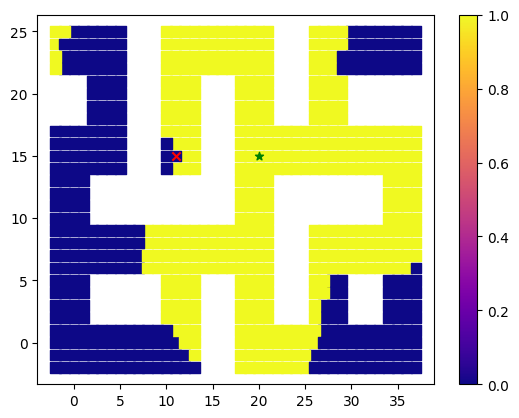

In [80]:
threshold = 0.0

c = plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=60, alpha=1.0, marker='s', c=(gamma_to_goal) < ob_to_goal + threshold, cmap='plasma')
plt.scatter(x=ob[0], y=ob[1], c='red', marker='x')
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.colorbar(c)
plt.show()

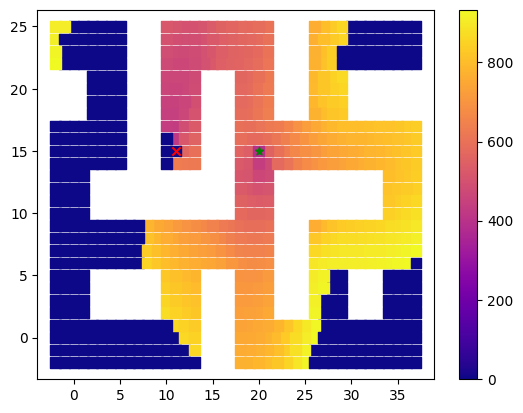

In [82]:
c = plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=60, alpha=1.0, marker='s', c=np.where(gamma_to_goal < ob_to_goal, gamma_to_subgoal + gamma_to_goal, -1), cmap='plasma')
plt.scatter(x=ob[0], y=ob[1], c='red', marker='x')
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.colorbar(c)
plt.show()

In [85]:
print(subgoals.shape)
print(ob.shape)
print(goal.shape)

(128, 2)
(2,)
(2,)


  0%|          | 0/200 [00:00<?, ?it/s]

 24%|██▍       | 49/200 [00:05<00:17,  8.63it/s]


no improving subgoal found at step 49


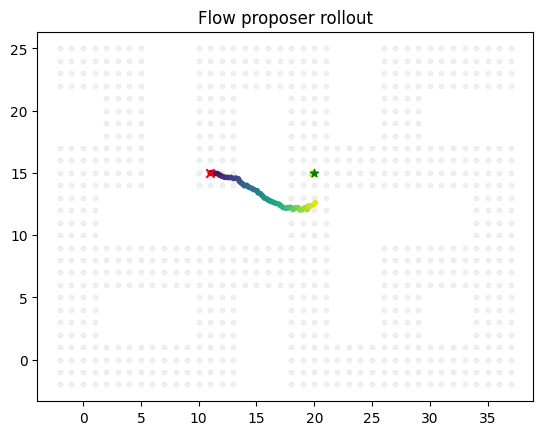

In [109]:
replay_buffer = []
rng = jax.random.PRNGKey(config['seed'])

ob = train_dataset.dataset['observations'][137060].copy()
start = ob[:2].copy()

for s in tqdm(range(200)):
    replay_buffer.append(ob[:2].copy())
    rng, sample_rng = jax.random.split(rng)
    subgoals = np.asarray(sample_n(ob, goal, 128, sample_rng))

    gamma_to_subgoal, gamma_to_goal, ob_to_goal = dynamical_distance(ob, subgoals, goal)
    gamma_to_subgoal = np.asarray(gamma_to_subgoal).reshape(-1)
    gamma_to_goal = np.asarray(gamma_to_goal).reshape(-1)
    ob_to_goal = float(np.asarray(ob_to_goal).reshape(-1)[0])

    mask = gamma_to_goal < ob_to_goal
    if not np.any(mask):
        print(f'no improving subgoal found at step {s}')
        break

    filtered_subgoals = subgoals[mask]
    filtered_scores = (gamma_to_subgoal + gamma_to_goal)[mask]
    subgoal = filtered_subgoals[int(np.argmin(filtered_scores))]

    if np.linalg.norm(subgoal - goal) < 0.005:
        replay_buffer.append(subgoal.copy())
        print(f'reached at step {s}!')
        print('subgoal:', subgoal)
        break

    # Keep the rest of the observation fixed and only move the xy/oracle part.
    # This is only appropriate if the downstream utilities read position from
    # the first two coordinates.
    ob = ob.copy()
    ob[:2] = subgoal

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

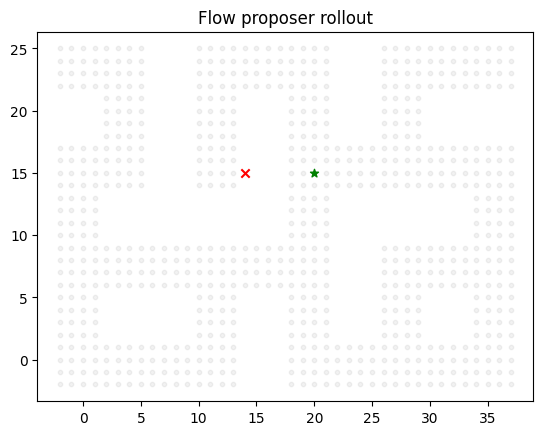

In [111]:
start = np.asarray([14.0, 15.0])
start_ob = ob.copy()
start_ob[:2] = start

plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

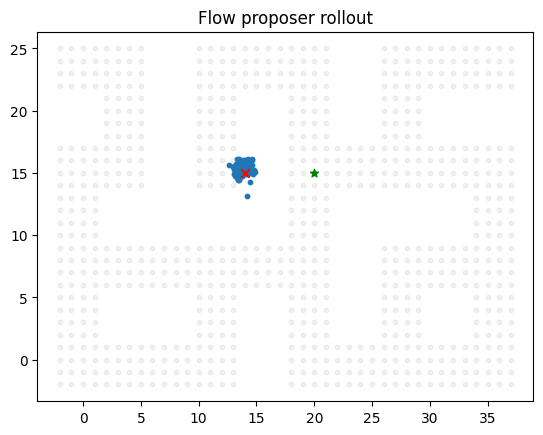

In [116]:
sample_rng, rng = jax.random.split(rng)
subgoals = sample_n(start_ob, goal, 128, sample_rng)

plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=subgoals[..., 0], y=subgoals[..., 1], s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

In [117]:
gamma_to_subgoal, gamma_to_goal, ob_to_goal = dynamical_distance(ob, subgoals, goal)
subgoals = subgoals[gamma_to_goal < ob_to_goal]
print(len(subgoals))

0


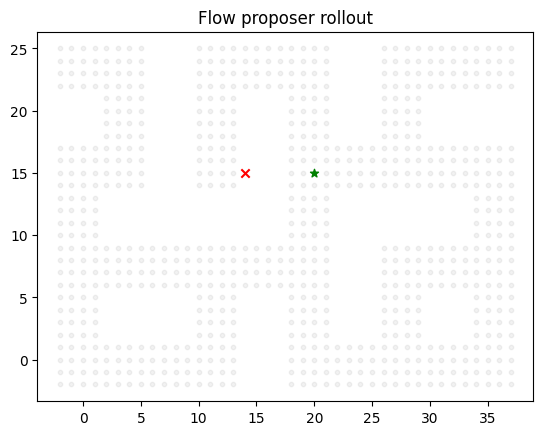

In [114]:
replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=subgoals[..., 0], y=subgoals[..., 1], s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

In [101]:
subgoal_idx = np.argmin((gamma_to_subgoal + gamma_to_goal)[gamma_to_goal < ob_to_goal])
subgoal = subgoals[subgoal_idx]

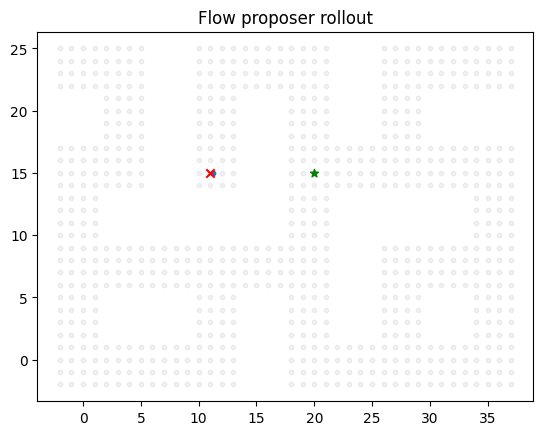

In [102]:
replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=subgoal[0], y=subgoal[1], s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

## How does it look outside of the maze?

In [118]:
print(all_cell_points[..., 0].min())
print(all_cell_points[..., 0].max())
print(all_cell_points[..., 1].min())
print(all_cell_points[..., 1].max())

-2.0
37.0
-2.0
25.0


In [131]:
import numpy as np

x = np.arange(-2.0, 38.0)
y = np.arange(-2.0, 26.0)

X, Y = np.meshgrid(x, y)

In [132]:
grid = np.stack([X.ravel(), Y.ravel()], axis=-1)  # shape: (N, 2)
print(grid.shape)

(1120, 2)


In [136]:
ob = train_dataset.dataset['observations'][137060].copy()

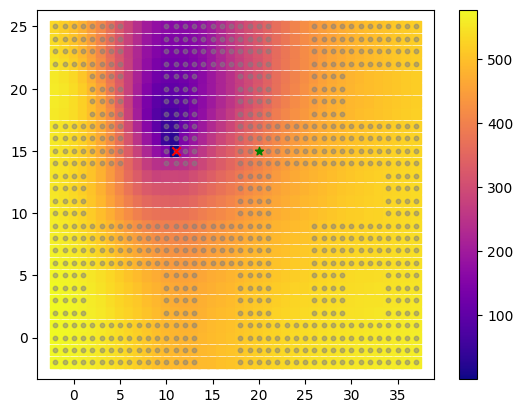

In [138]:
gamma_to_subgoal, gamma_to_goal, ob_to_goal = dynamical_distance(ob, grid, goal)

c = plt.scatter(x=grid[..., 0], y=grid[..., 1], s=60, alpha=1.0, marker='s', c=gamma_to_subgoal, cmap='plasma')
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.5, c='gray')

plt.scatter(x=ob[0], y=ob[1], c='red', marker='x')
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.colorbar(c)
plt.show()

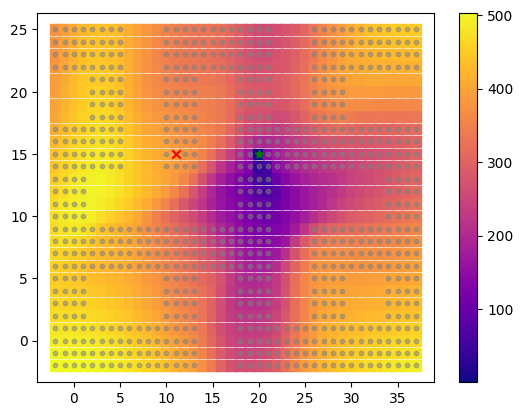

In [139]:
c = plt.scatter(x=grid[..., 0], y=grid[..., 1], s=60, alpha=1.0, marker='s', c=gamma_to_goal, cmap='plasma')
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.5, c='gray')

plt.scatter(x=ob[0], y=ob[1], c='red', marker='x')
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.colorbar(c)
plt.show()

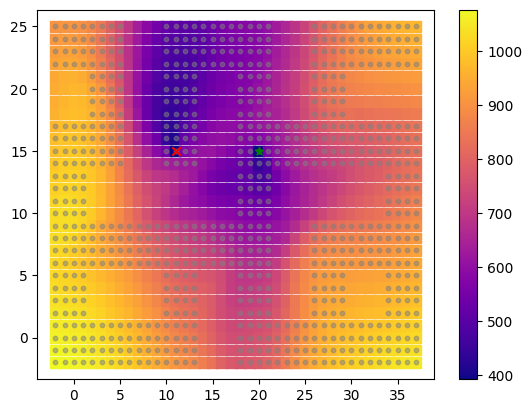

In [140]:
c = plt.scatter(x=grid[..., 0], y=grid[..., 1], s=60, alpha=1.0, marker='s', c=gamma_to_subgoal + gamma_to_goal, cmap='plasma')
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.5, c='gray')

plt.scatter(x=ob[0], y=ob[1], c='red', marker='x')
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.colorbar(c)
plt.show()

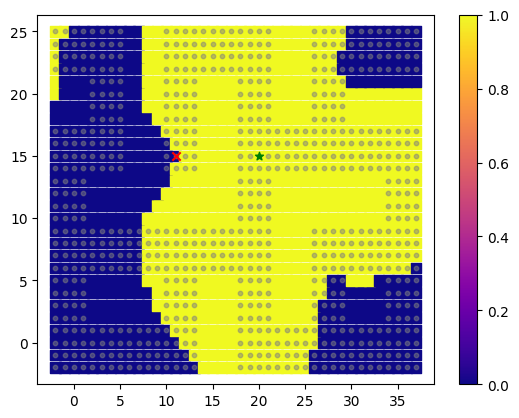

In [141]:
c = plt.scatter(x=grid[..., 0], y=grid[..., 1], s=60, alpha=1.0, marker='s', c=(gamma_to_goal < ob_to_goal), cmap='plasma')
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.5, c='gray')

plt.scatter(x=ob[0], y=ob[1], c='red', marker='x')
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.colorbar(c)
plt.show()

In [143]:
dqc_agent.config['best_of_n']

4

## Testing DQC agent

In [145]:
action_rng, rng = jax.random.split(rng)
dqc_agent.sample_actions(observations=ob, goals=goal, seed=action_rng)

Array([-1.        , -0.08060621,  0.8125545 , -0.8479846 , -0.7372001 ,
        0.7730706 ,  0.93068177,  0.7523711 ,  0.1747112 ,  0.853022  ,
       -0.8257514 ,  0.5433771 ,  0.07199194,  0.95856094, -0.91169345,
        0.47245076,  0.9561742 ,  0.957117  , -0.343654  ,  1.        ,
        0.97938794], dtype=float32)

In [158]:
env.spec.id

'humanoidmaze-medium-v0'

In [171]:
replay_buffer = []
# ob = train_dataset.dataset['observations'][137060].copy()
ob, _ = env.reset()
start = ob.copy()[:2]
goal = np.asarray([20.0, 15.0])

for i in tqdm(range(2000)):
    replay_buffer.append(ob)
    action_rng, rng = jax.random.split(rng)
    action = dqc_agent.sample_actions(observations=ob, goals=goal, seed=action_rng)
    ob, reward, terminated, truncated, _ = env.step(action)

  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [00:05<00:00, 351.40it/s]


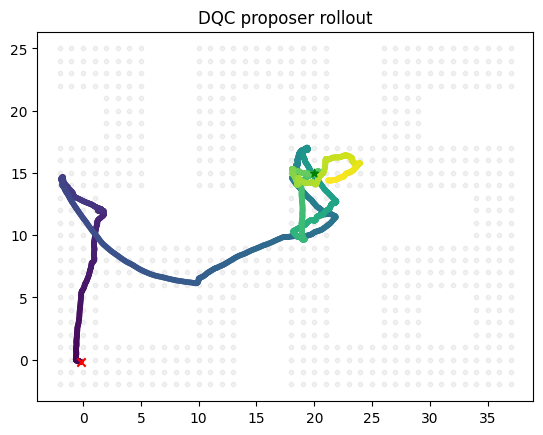

In [172]:
replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=start[0], y=start[1], marker='x', c='red')
plt.title('DQC proposer rollout')
plt.show()

In [ ]:
replay_buffer = []
subgoals = []

# ob = train_dataset.dataset['observations'][137060].copy()
ob, _ = env.reset()
start = ob.copy()[:2]
goal = np.asarray([20.0, 15.0])
subgoal = None

for i in tqdm(range(2000)):
    replay_buffer.append(ob)

    if subgoal is None:
        

    action_rng, rng = jax.random.split(rng)
    action = dqc_agent.sample_actions(observations=ob, goals=goal, seed=action_rng)
    ob, reward, terminated, truncated, _ = env.step(action)